Original shape: (20640, 10)
Cleaned shape: (20640, 13)

Basic Statistics:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20640.000000  20640.000000  20640.000000   20640.000000   
mean       536.838857   1425.476744    499.539680       3.870671   
std        419.391878   1132.462122    382.329753       1.899822   
min          1

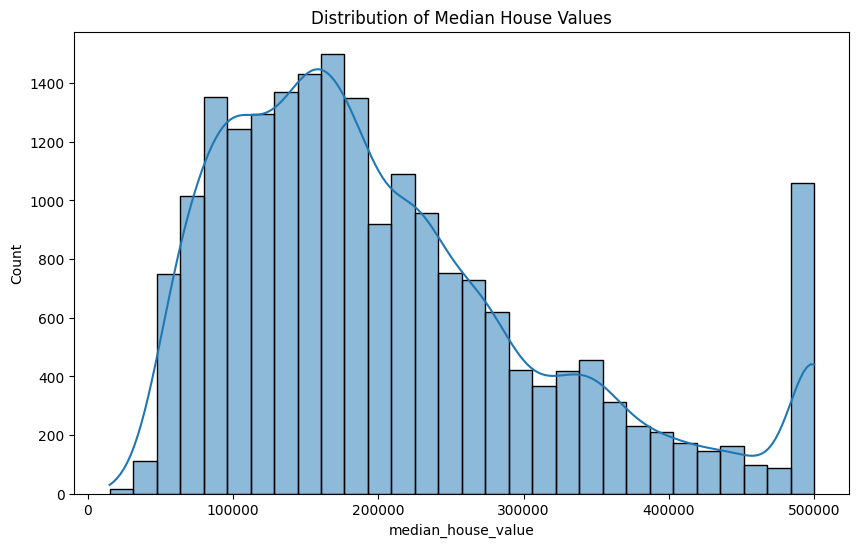

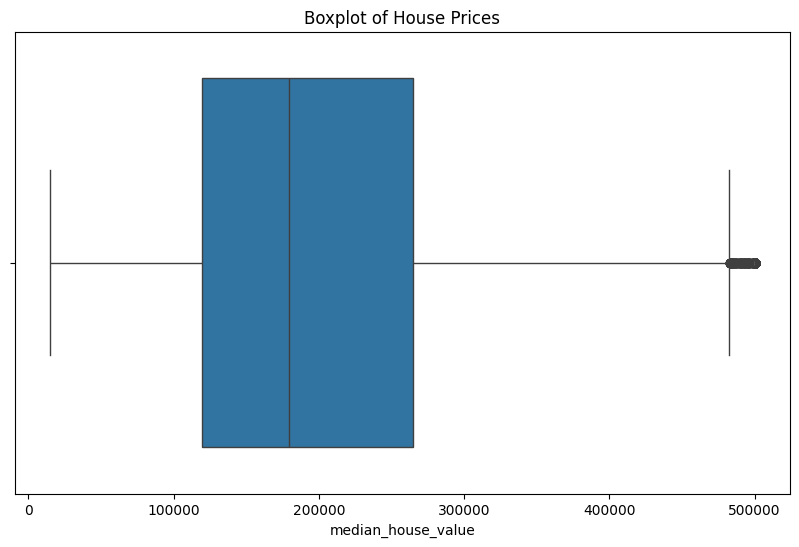

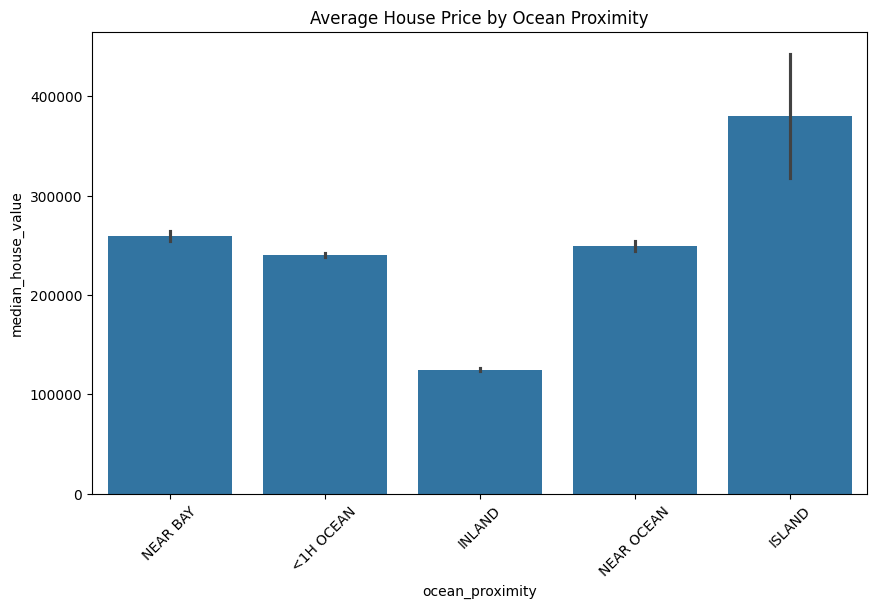

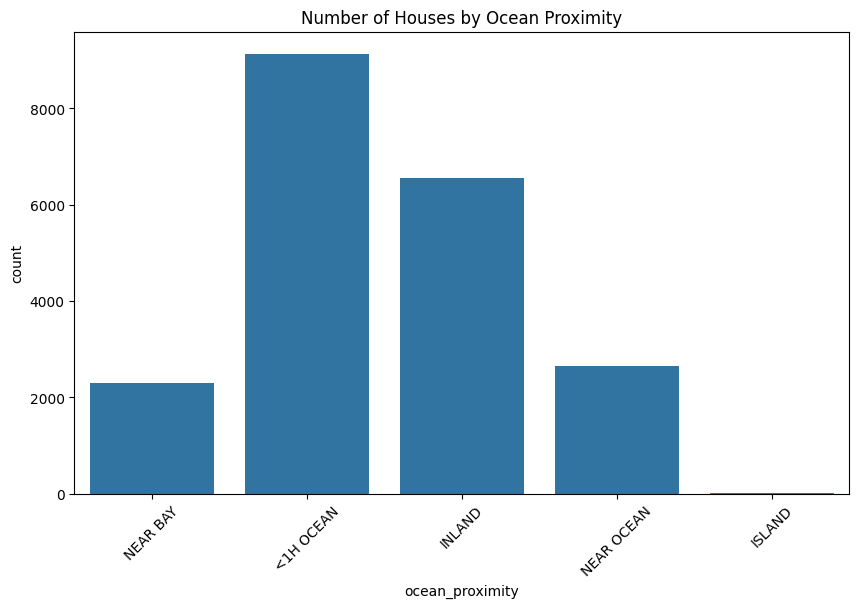

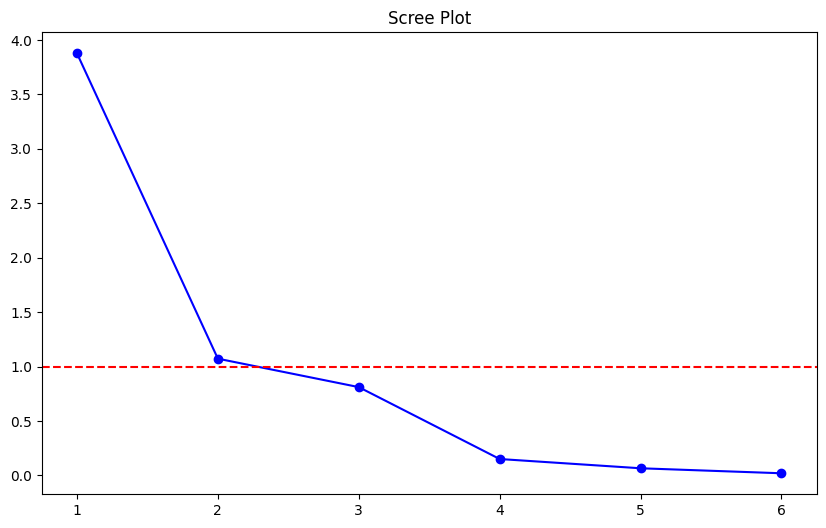

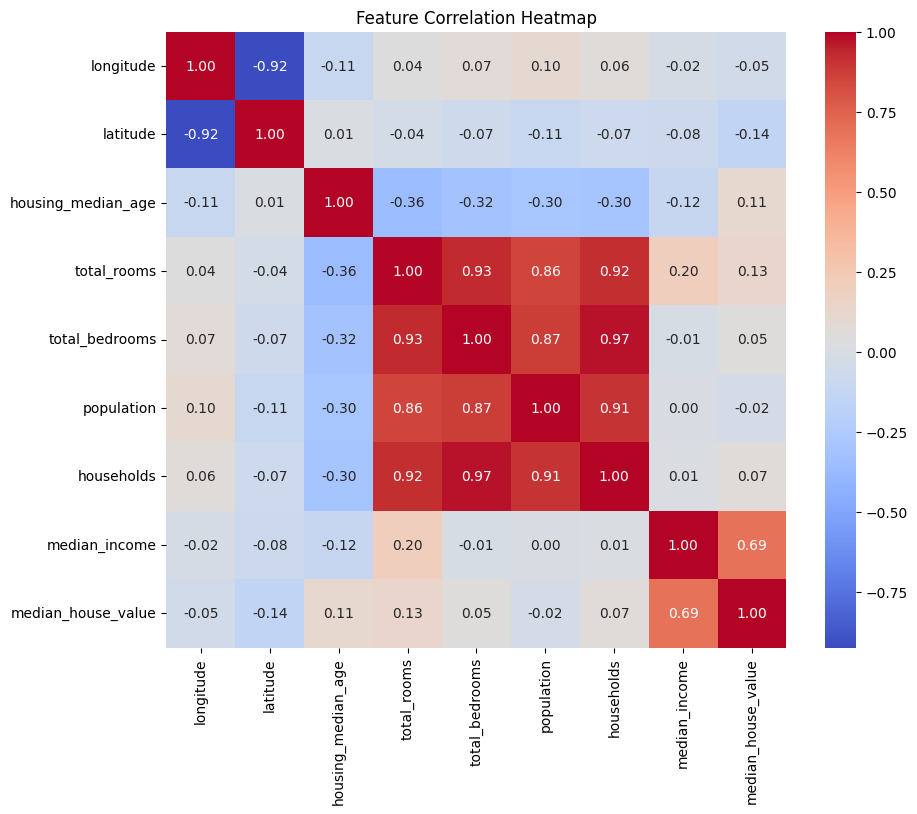

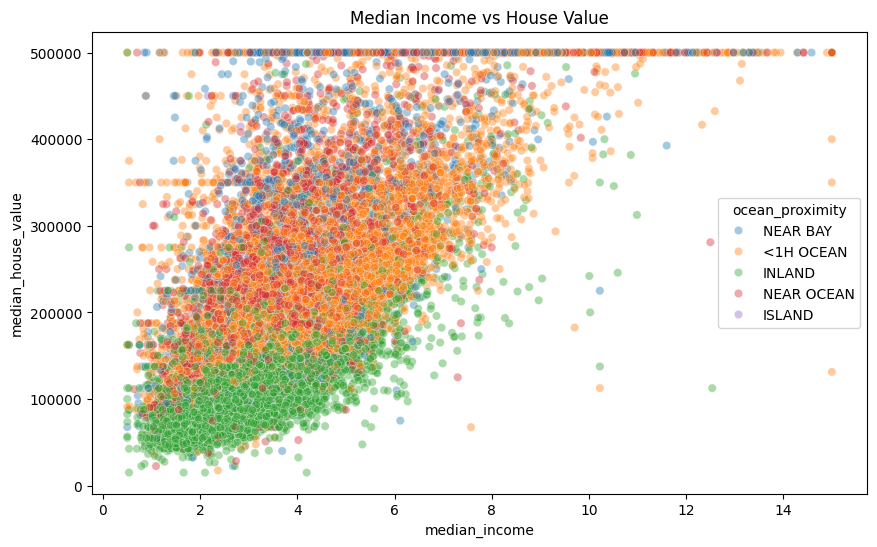


Linear Regression → R2: 0.64
Random Forest → R2: 0.82


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step
Neural Network → R2: 0.68


In [8]:
# ==================== 1.Clean and Preprocess data====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

#2. Load data
df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv')
print("Original shape:", df.shape)

# Keep original ocean_proximity for plots
ocean_prox = df['ocean_proximity'].copy()

# ====================== 3. CLEAN AND PREPROCESS ======================
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
print("Cleaned shape:", df.shape)

# ====================== 4. EXPLORATORY DATA ANALYSIS  ======================
numeric_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                'total_bedrooms', 'population', 'households', 'median_income',
                'median_house_value']

print("\nBasic Statistics:")
print(df[numeric_cols].describe())

# Figure 1: Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['median_house_value'], bins=30, kde=True)
plt.title("Distribution of Median House Values")
plt.savefig('fig1_distribution.png', dpi=300)
plt.show()

# Figure 2: Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x=df['median_house_value'])
plt.title("Boxplot of House Prices")
plt.savefig('fig2_boxplot.png', dpi=300)
plt.show()

# Figure 3: Average Price by Ocean Proximity
plt.figure(figsize=(10,6))
sns.barplot(x=ocean_prox, y=df['median_house_value'])
plt.title("Average House Price by Ocean Proximity")
plt.xticks(rotation=45)
plt.savefig('fig3_avg_ocean.png', dpi=300)
plt.show()

# Figure 4: Count by Ocean Proximity
plt.figure(figsize=(10,6))
sns.countplot(x=ocean_prox)
plt.title("Number of Houses by Ocean Proximity")
plt.xticks(rotation=45)
plt.savefig('fig4_count_ocean.png', dpi=300)
plt.show()

# Figure 5: PCA Scree Plot
features_pca = ['total_rooms', 'total_bedrooms', 'population', 'households',
                'median_income', 'housing_median_age']
X_pca = StandardScaler().fit_transform(df[features_pca])
pca = PCA().fit(X_pca)
plt.figure(figsize=(10,6))
plt.plot(range(1, len(pca.explained_variance_)+1), pca.explained_variance_, 'bo-')
plt.title('Scree Plot')
plt.axhline(y=1, color='r', linestyle='--')
plt.savefig('fig5_scree.png', dpi=300)
plt.show()

# Figure 6: Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.savefig('fig6_heatmap.png', dpi=300)
plt.show()

# Figure 7: Median Income vs House Value Scatter
plt.figure(figsize=(10,6))
sns.scatterplot(x='median_income', y='median_house_value', data=df, hue=ocean_prox, alpha=0.4)
plt.title("Median Income vs House Value")
plt.savefig('fig7_scatter.png', dpi=300)
plt.show()



# ====================== 5. ML MODELS ======================
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=88)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("\nLinear Regression → R2:", round(r2_score(y_test, lr_pred), 2))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=88)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest → R2:", round(r2_score(y_test, rf_pred), 2))

# Neural Network (exactly like example)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train_s, y_train, epochs=50, batch_size=32, validation_data=(X_test_s, y_test), verbose=0)

nn_pred = model.predict(X_test_s).flatten()
print("Neural Network → R2:", round(r2_score(y_test, nn_pred), 2))

